# Phase 1 - ResNet-50 (CNN Architecture)

**Project:** Comparing CNN, ViT, and Hybrid architecture for Pneumonia detection with systematic Grad-CAM analysis    

### Purpose of this notebook

This notebook trains **ResNet-50** (the pure CNN architecture) to classify the xray images whether pneumonia patient or not.


## 1. Environment setup
We redirect the cache to our home directory so `timm` can download pretrained weights without permission errors.


In [1]:
import os
# Redirect HuggingFace/timm cache to a directory we have write access to
os.environ["HF_HOME"] = "/home/2914/.cache/huggingface"
os.environ["TRANSFORMERS_CACHE"] = "/home/2914/.cache/huggingface"
os.environ["HF_HUB_CACHE"] = "/home/2914/.cache/huggingface/hub"

print(f"HF_HOME set to: {os.environ['HF_HOME']}")

HF_HOME set to: /home/2914/.cache/huggingface


## 2. Imports and GPU check

Imports the shared modules from `src/`:
- `data.py` provides `get_fold_loaders()` (train/val loaders for one fold), `get_test_loader()` (held-out test set), and `print_fold_info()`
- `train.py` provides `train_one_fold()` (trains one fold), `compute_class_weights()`, and `set_seed()`
- `ensemble.py` provides `evaluate_ensemble()` (soft-voting evaluation on the test set)


In [2]:
import sys
import json
import time
from pathlib import Path
import torch

sys.path.insert(0, str(Path.cwd().parent / "src"))

from data import get_fold_loaders, get_test_loader, print_fold_info, _get_pooled_training_samples
from train import train_one_fold, compute_class_weights, set_seed
from ensemble import evaluate_ensemble

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch: 2.8.0+cu129
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 8.16 GB


## 3. Configuration

All settings in one place. `N_SPLITS=5` is the number of cross-validation folds. The learning rate is 1e-3 for ResNet (the literature-standard CNN rate, matching the paper).


In [ ]:
MODEL_NAME = "resnet50"
N_SPLITS = 5         # 5-fold cross-validation
BATCH_SIZE = 16      # same for all 3 models at 384px
EPOCHS = 10          # epochs per fold
LR = 1e-3            
SEED = 42
NUM_WORKERS = 4

## 4. Verify the fold split

Before training, we print the size and class balance of each fold and confirm the held-out test set is separate.The test set should be 624 images and never appear inside a fold.


In [4]:
print_fold_info(n_splits=N_SPLITS, seed=SEED)

Pooled training images (train + val): 5232 (1349 NORMAL, 3883 PNEUMONIA)
Held-out TEST set (never used in training): 624 (234 NORMAL, 390 PNEUMONIA)

  Fold 0: train=4185, val=1047 (270 NORMAL, 777 PNEUMONIA)
  Fold 1: train=4185, val=1047 (270 NORMAL, 777 PNEUMONIA)
  Fold 2: train=4186, val=1046 (270 NORMAL, 776 PNEUMONIA)
  Fold 3: train=4186, val=1046 (270 NORMAL, 776 PNEUMONIA)
  Fold 4: train=4186, val=1046 (269 NORMAL, 777 PNEUMONIA)


## 5. Train all 5 folds

We loop over the 5 folds. For each fold:
1. Get that fold's training and validation loaders.
2. Compute class weights from that fold's training data (handles imbalance).
3. Train the model and save the fold's best checkpoint (by validation F1).



In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Will hold the per-fold training history and checkpoint paths
fold_summaries = []
fold_checkpoints = []

t0 = time.time()

for fold_index in range(N_SPLITS):
    print("=" * 60)
    print(f"TRAINING FOLD {fold_index} / {N_SPLITS - 1}")
    print("=" * 60)

    # 1. Get this fold's train and validation loaders
    train_loader, val_loader = get_fold_loaders(
        fold_index=fold_index,
        n_splits=N_SPLITS,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        seed=SEED,
    )

    # 2. Compute class weights from THIS fold's training samples
    class_weights = compute_class_weights(train_loader.dataset.samples, torch.device(device))
    print(f"Class weights [NORMAL, PNEUMONIA]: {class_weights.tolist()}")

    # 3. Train this fold and save its checkpoint
    fold_result = train_one_fold(
        model_name=MODEL_NAME,
        train_loader=train_loader,
        val_loader=val_loader,
        fold_index=fold_index,
        epochs=EPOCHS,
        lr=LR,
        device=device,
        checkpoint_dir="../checkpoints",
        seed=SEED,
        class_weights=class_weights,
    )

    fold_summaries.append(fold_result)
    fold_checkpoints.append(fold_result["checkpoint_path"])

total_time = time.time() - t0
print(f"\nAll {N_SPLITS} folds trained in {total_time/60:.1f} minutes")

TRAINING FOLD 0 / 4
Class weights [NORMAL, PNEUMONIA]: [1.9392956495285034, 0.6736961007118225]
[Fold 0] resnet50 (23,512,130 params) | AdamW lr=0.001 | weighted CE | epochs=10 | device=cuda
[Fold 0] Mixed precision (AMP/FP16) enabled
[Fold 0] train batches=262, val batches=66
------------------------------------------------------------


[Fold 0] Epoch  1/10 | train_loss=0.2427 | val_loss=0.1062 | val_acc=0.9656 val_f1=0.9649 | 35.0s
  -> [Fold 0] New best F1, saved: resnet50_fold0_best.pth


[Fold 0] Epoch  2/10 | train_loss=0.1547 | val_loss=0.2483 | val_acc=0.8930 val_f1=0.8979 | 36.0s


[Fold 0] Epoch  3/10 | train_loss=0.1420 | val_loss=0.0996 | val_acc=0.9704 val_f1=0.9699 | 34.6s
  -> [Fold 0] New best F1, saved: resnet50_fold0_best.pth


[Fold 0] Epoch  4/10 | train_loss=0.1257 | val_loss=0.4911 | val_acc=0.8309 val_f1=0.8409 | 34.2s


...

[Fold 4] Epoch  6/10 | train_loss=0.0828 | val_loss=0.2243 | val_acc=0.9321 val_f1=0.9344 | 34.3s


[Fold 4] Epoch  7/10 | train_loss=0.0977 | val_loss=0.1428 | val_acc=0.9522 val_f1=0.9533 | 34.4s


[Fold 4] Epoch  8/10 | train_loss=0.0898 | val_loss=0.1423 | val_acc=0.9474 val_f1=0.9488 | 34.3s


[Fold 4] Epoch  9/10 | train_loss=0.0893 | val_loss=0.0946 | val_acc=0.9656 val_f1=0.9660 | 34.4s


[Fold 4] Epoch 10/10 | train_loss=0.0766 | val_loss=0.3224 | val_acc=0.9168 val_f1=0.9201 | 34.3s
------------------------------------------------------------
[Fold 4] Done. Best val F1 = 0.9686 (epoch 3)

All 5 folds trained in 29.0 minutes


## 6. Evaluate the ensemble on the test set

Now we combine the 5 fold-models into a soft-voting ensemble: each model predicts a probability for every test image, we average the 5 probabilities, and pick the higher class. 


In [6]:
# Load the held-out test set (the paper's 624 images)
test_loader = get_test_loader(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# Evaluate the soft-voting ensemble of all 5 fold-models
ensemble_metrics = evaluate_ensemble(
    model_name=MODEL_NAME,
    fold_checkpoints=fold_checkpoints,
    test_loader=test_loader,
    device=device,
)

Building ensemble for resnet50 from 5 folds
Device: cuda
  Loading fold 0: resnet50_fold0_best.pth


  Loading fold 1: resnet50_fold1_best.pth


  Loading fold 2: resnet50_fold2_best.pth


  Loading fold 3: resnet50_fold3_best.pth


  Loading fold 4: resnet50_fold4_best.pth



Ensemble test results:
  Accuracy:        0.9359
  F1 (weighted):   0.9346
  Precision:       0.9405
  Recall:          0.9359
  Recall NORMAL:   0.8376
  Recall PNEUMONIA:0.9949
  Confusion matrix: [[196, 38], [2, 388]]


## 7. Save results

We save everything needed for the report: each fold's best validation F1, the per-fold training histories (for the curves), and the final ensemble test metrics.


In [7]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Build a clean, JSON-serializable summary
serializable = {
    "model_name": MODEL_NAME,
    "n_splits": N_SPLITS,
    "total_training_time_minutes": total_time / 60,
    "fold_best_val_f1": [float(f["best_val_f1"]) for f in fold_summaries],
    "fold_best_epoch": [int(f["best_epoch"]) for f in fold_summaries],
    "fold_histories": [
        {
            "fold_index": f["fold_index"],
            "train_loss": [float(x) for x in f["history"]["train_loss"]],
            "val_loss": [float(m["loss"]) for m in f["history"]["val_metrics"]],
            "val_f1": [float(m["f1"]) for m in f["history"]["val_metrics"]],
        }
        for f in fold_summaries
    ],
    "ensemble_test_metrics": {
        k: (float(v) if isinstance(v, (int, float)) else v)
        for k, v in ensemble_metrics.items()
    },
}

out_path = results_dir / f"{MODEL_NAME}_kfold_results.json"
with open(out_path, "w") as f:
    json.dump(serializable, f, indent=2)

print(f"Results saved to: {out_path}")
print(f"\nMean fold val F1: {sum(serializable['fold_best_val_f1'])/N_SPLITS:.4f}")
print(f"Ensemble test F1: {ensemble_metrics['f1']:.4f}")
print(f"Ensemble test accuracy: {ensemble_metrics['accuracy']:.4f}")

Results saved to: ../results/resnet50_kfold_results.json

Mean fold val F1: 0.9772
Ensemble test F1: 0.9346
Ensemble test accuracy: 0.9359


## 8. Evaluation metircs
A short text summary of the final ensemble performance is printed below the figure.
We plot training loss and validation F1 on the same axis.

Figure saved: ../results/figures/resnet50_mean_loss_f1_curve.png


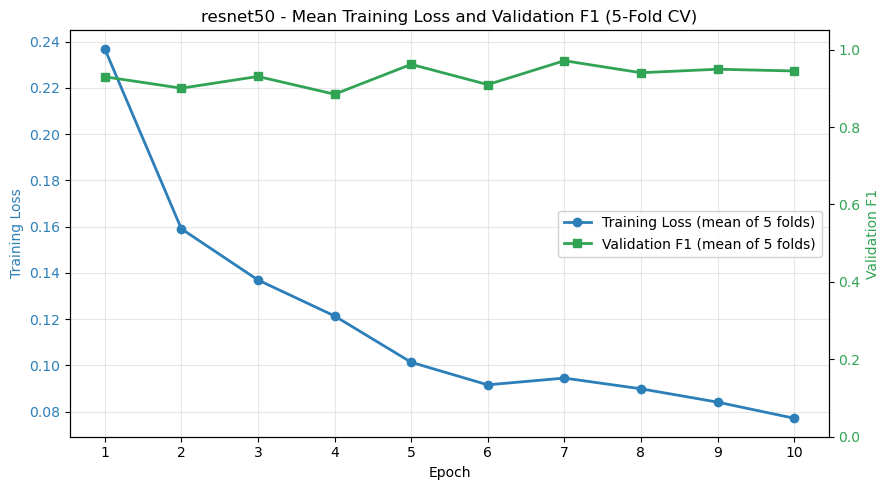


--- resnet50 summary ---
Mean fold validation F1:   0.9772 ± 0.0076
Ensemble test accuracy:    0.9359
Ensemble test F1:          0.9346
Ensemble Recall NORMAL:    0.8376
Ensemble Recall PNEUMONIA: 0.9949
Sensitivity (PNEUMONIA):   0.9949
Specificity (NORMAL):      0.8376
Balanced accuracy:         0.9162
Cohen's Kappa:             0.8589
Missed pneumonia (FN):     2 / 390
False alarms (FP):         38 / 234


In [8]:
import matplotlib.pyplot as plt
import numpy as np

with open(f"../results/{MODEL_NAME}_kfold_results.json") as f:
    results = json.load(f)

# Average across the 5 folds at each epoch
all_train = np.array([f["train_loss"] for f in results["fold_histories"]])
all_f1 = np.array([f["val_f1"] for f in results["fold_histories"]])
mean_train = all_train.mean(axis=0)
mean_f1 = all_f1.mean(axis=0)
epochs = list(range(1, len(mean_train) + 1))

fig, ax1 = plt.subplots(figsize=(9, 5))

# Training loss (left axis)
color_train = "#2c7fb8"
l1 = ax1.plot(epochs, mean_train, marker="o", color=color_train, linewidth=2,
              label="Training Loss (mean of 5 folds)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color=color_train)
ax1.tick_params(axis="y", labelcolor=color_train)
ax1.set_xticks(epochs)
ax1.grid(alpha=0.3)

# Validation F1 (right axis)
ax2 = ax1.twinx()
color_val = "#31a354"
l2 = ax2.plot(epochs, mean_f1, marker="s", color=color_val, linewidth=2,
              label="Validation F1 (mean of 5 folds)")
ax2.set_ylabel("Validation F1", color=color_val)
ax2.tick_params(axis="y", labelcolor=color_val)
ax2.set_ylim(0, 1.05)

lines = l1 + l2
ax1.legend(lines, [l.get_label() for l in lines], loc="center right", framealpha=0.9)
ax1.set_title(f"{MODEL_NAME} - Mean Training Loss and Validation F1 (5-Fold CV)")
fig.tight_layout()

fig_dir = Path("../results/figures")
fig_dir.mkdir(exist_ok=True)
fig_path = fig_dir / f"{MODEL_NAME}_mean_loss_f1_curve.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure saved: {fig_path}")
plt.show()

# ============================================================
# Metrics summary (from saved JSON)
# ============================================================
m = results["ensemble_test_metrics"]
cm = m["confusion_matrix"]
tn, fp = cm[0][0], cm[0][1]
fn, tp = cm[1][0], cm[1][1]
total = tn + fp + fn + tp

# Cohen's Kappa from the confusion matrix (matches the base paper's metric)
p_obs = (tn + tp) / total
p_exp = (((tn + fp) * (tn + fn)) + ((fn + tp) * (fp + tp))) / (total ** 2)
kappa = (p_obs - p_exp) / (1 - p_exp)

# Extra derived metrics
specificity = tn / (tn + fp)
balanced_acc = (m["recall_normal"] + m["recall_pneumonia"]) / 2
fold_f1s = results["fold_best_val_f1"]

print(f"\n--- {MODEL_NAME} summary ---")
print(f"Mean fold validation F1:   {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Ensemble test accuracy:    {m['accuracy']:.4f}")
print(f"Ensemble test F1:          {m['f1']:.4f}")
print(f"Ensemble Recall NORMAL:    {m['recall_normal']:.4f}")
print(f"Ensemble Recall PNEUMONIA: {m['recall_pneumonia']:.4f}")
print(f"Sensitivity (PNEUMONIA):   {m['recall_pneumonia']:.4f}")
print(f"Specificity (NORMAL):      {specificity:.4f}")
print(f"Balanced accuracy:         {balanced_acc:.4f}")
print(f"Cohen's Kappa:             {kappa:.4f}")
print(f"Missed pneumonia (FN):     {fn} / {tp + fn}")
print(f"False alarms (FP):         {fp} / {tn + fp}")